# 01 - Exploration SQL Server

**Architecture:**
- Requêtes SQL → `sql/` (fichiers .sql)
- Code Python → Ce notebook (lit depuis `sql/`)
- Fix warning seaborn ✅ (hue + legend=False)

## 1. Imports et Configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import yaml
from pathlib import Path

# Configuration
PROJECT_ROOT = Path("/home/esprit/airlLines_Project")
SQL_DIR = PROJECT_ROOT / "sql"

with open(PROJECT_ROOT / "config" / "config.yaml", 'r') as f:
    config = yaml.safe_load(f)

sql_config = config['sql']

# Engine SQLAlchemy
connection_string = f"mssql+pymssql://{sql_config['user']}:{sql_config['password']}@{sql_config['server']}:{sql_config['port']}/{sql_config['databases']['dwh']}"
engine = create_engine(connection_string)

# Configuration visualisation
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Configuration chargée")
print(f"🗄️  Base: {sql_config['databases']['dwh']}")
print(f"📂 SQL: {SQL_DIR}")

✅ Configuration chargée
🗄️  Base: airlines_dwh
📂 SQL: /home/esprit/airlLines_Project/sql


## 2. Vue d'ensemble des tables

📊 Tables et volumes:


,table_name,row_count
0,fact_Flights,392936
1,fact_revenu,392936
2,FACT_REVIEW,129880
3,DIM_CLIENT,16737
4,DIM_TIME,14976
5,Dim_Location,64


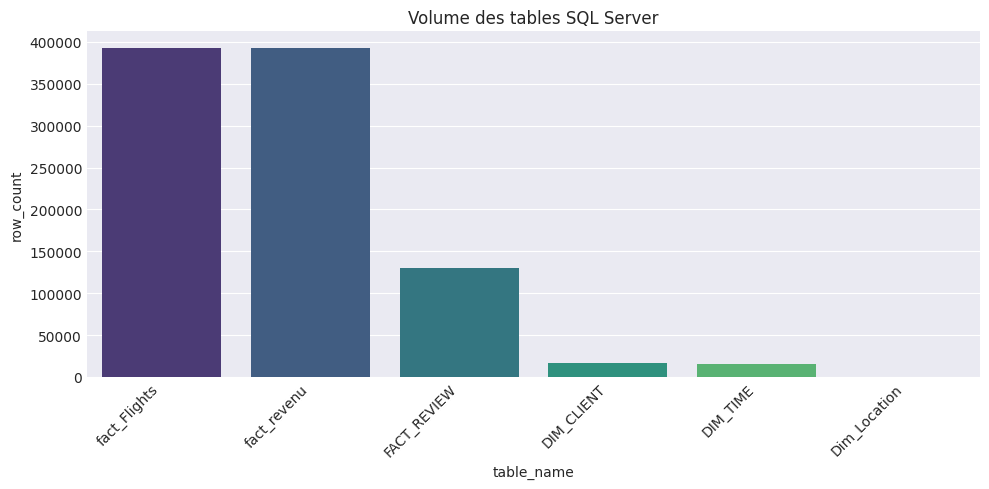

In [10]:
# Lecture requête depuis fichier SQL
with open(SQL_DIR / "00_overview_tables.sql", 'r') as f:
    query_tables = f.read()

df_tables = pd.read_sql(query_tables, engine)

print("📊 Tables et volumes:")
display(df_tables)

# Graphique
plt.figure(figsize=(10, 5))
sns.barplot(data=df_tables, x='table_name', y='row_count', hue='table_name', 
           palette='viridis', legend=False)
plt.title('Volume des tables SQL Server')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Exploration FACT_REVIEW - Données de satisfaction

In [11]:
# Lecture requête depuis fichier SQL
with open(SQL_DIR / "01_extraction_dwh.sql", 'r') as f:
    full_sql = f.read()

# Extraire la requête FACT_REVIEW
import re
match = re.search(r'-- Extraction FACT_REVIEW.*?;(?=\n\n|--|$)', full_sql, re.DOTALL)
if match:
    query_fact_review = match.group(0).strip()
else:
    query_fact_review = "SELECT * FROM FACT_REVIEW;"

df_fact_review = pd.read_sql(query_fact_review, engine)

print(f"📊 FACT_REVIEW: {df_fact_review.shape}")
print(f"\nColonnes: {list(df_fact_review.columns)}")
print(f"\nAperçu:")
display(df_fact_review.head())

📊 FACT_REVIEW: (129880, 24)

Colonnes: ['review_sk', 'client_sk', 'time_sk', 'customer_type', 'traveller_type', 'travel_class', 'flight_distance', 'departure_delay', 'arrival_delay', 'departure_arrival_conv_score', 'online_booking_score', 'checkin_service_score', 'online_boarding_score', 'gate_location_score', 'onboard_service_score', 'seat_comfort_score', 'legroom_score', 'cleanliness_score', 'food_drink_score', 'inflight_service_score', 'wifi_score', 'entertainment_score', 'baggage_score', 'satisfaction_status']

Aperçu:


,review_sk,client_sk,time_sk,customer_type,traveller_type,travel_class,flight_distance,departure_delay,arrival_delay,departure_arrival_conv_score,...,onboard_service_score,seat_comfort_score,legroom_score,cleanliness_score,food_drink_score,inflight_service_score,wifi_score,entertainment_score,baggage_score,satisfaction_status
0,1,829,20240102,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,887,20240103,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,854,20240104,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,1906,20240105,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,3472,20240106,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 4. Distribution de la satisfaction

📊 Distribution de satisfaction:
   Neutral or Dissatisfied: 73,452 (56.6%)
   Satisfied: 56,428 (43.4%)


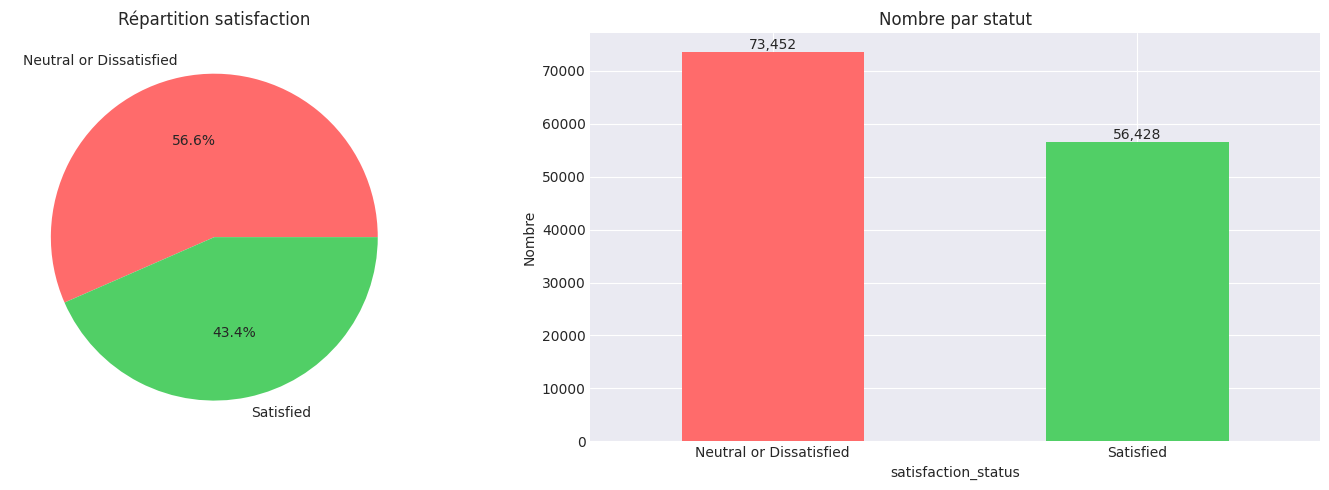

In [12]:
satisfaction_counts = df_fact_review['satisfaction_status'].value_counts()
satisfaction_pct = df_fact_review['satisfaction_status'].value_counts(normalize=True) * 100

print("📊 Distribution de satisfaction:")
for status, count in satisfaction_counts.items():
    print(f"   {status}: {count:,} ({satisfaction_pct[status]:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].pie(satisfaction_counts.values, labels=satisfaction_counts.index, 
           autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
axes[0].set_title('Répartition satisfaction')

satisfaction_counts.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#51cf66'])
axes[1].set_title('Nombre par statut')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(satisfaction_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Analyse des scores de service

📊 Moyenne des scores (tous les clients):


,Moyenne
avg_departure_arrival_conv,3
avg_online_booking,2
avg_checkin,3
avg_online_boarding,3
avg_gate,2
avg_onboard,3
avg_seat,3
avg_legroom,3
avg_cleanliness,3
avg_food,3


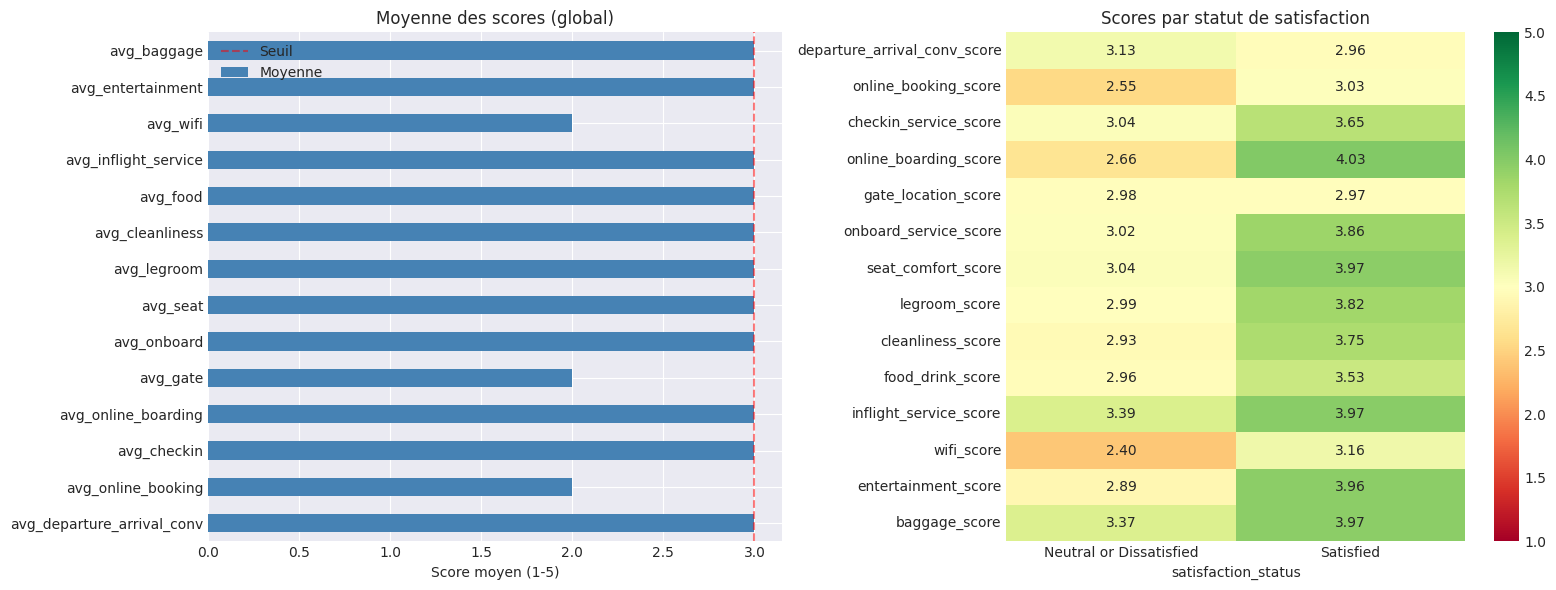

In [13]:
# Lecture requête depuis fichier SQL
with open(SQL_DIR / "04_scores_analysis.sql", 'r') as f:
    query_scores = f.read()

df_scores_mean = pd.read_sql(query_scores, engine)

# Transposer pour affichage
df_scores_T = df_scores_mean.T
df_scores_T.columns = ['Moyenne']

print("📊 Moyenne des scores (tous les clients):")
display(df_scores_T)

# CORRECTION - utiliser les noms réels des colonnes df_fact_review
score_columns = [
    'departure_arrival_conv_score', 'online_booking_score', 'checkin_service_score',
    'online_boarding_score', 'gate_location_score', 'onboard_service_score',
    'seat_comfort_score', 'legroom_score', 'cleanliness_score', 'food_drink_score',
    'inflight_service_score', 'wifi_score', 'entertainment_score', 'baggage_score'
]

# Calcul moyennes par statut de satisfaction
score_by_satisfaction = df_fact_review.groupby('satisfaction_status')[score_columns].mean()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_scores_T.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Moyenne des scores (global)')
axes[0].set_xlabel('Score moyen (1-5)')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Seuil')
axes[0].legend()

score_by_satisfaction_T = score_by_satisfaction.T
sns.heatmap(score_by_satisfaction_T, annot=True, fmt='.2f', cmap='RdYlGn', 
           vmin=1, vmax=5, ax=axes[1])
axes[1].set_title('Scores par statut de satisfaction')

plt.tight_layout()
plt.show()

## 6. Impact des retards sur la satisfaction

📊 Satisfaction par catégorie de retard:

satisfaction_status  Neutral or Dissatisfied  Satisfied
delay_category                                         
Early                                   52.6       47.4
On Time                                 58.8       41.2
Minor Delay                             64.1       35.9
Major Delay                             64.4       35.6


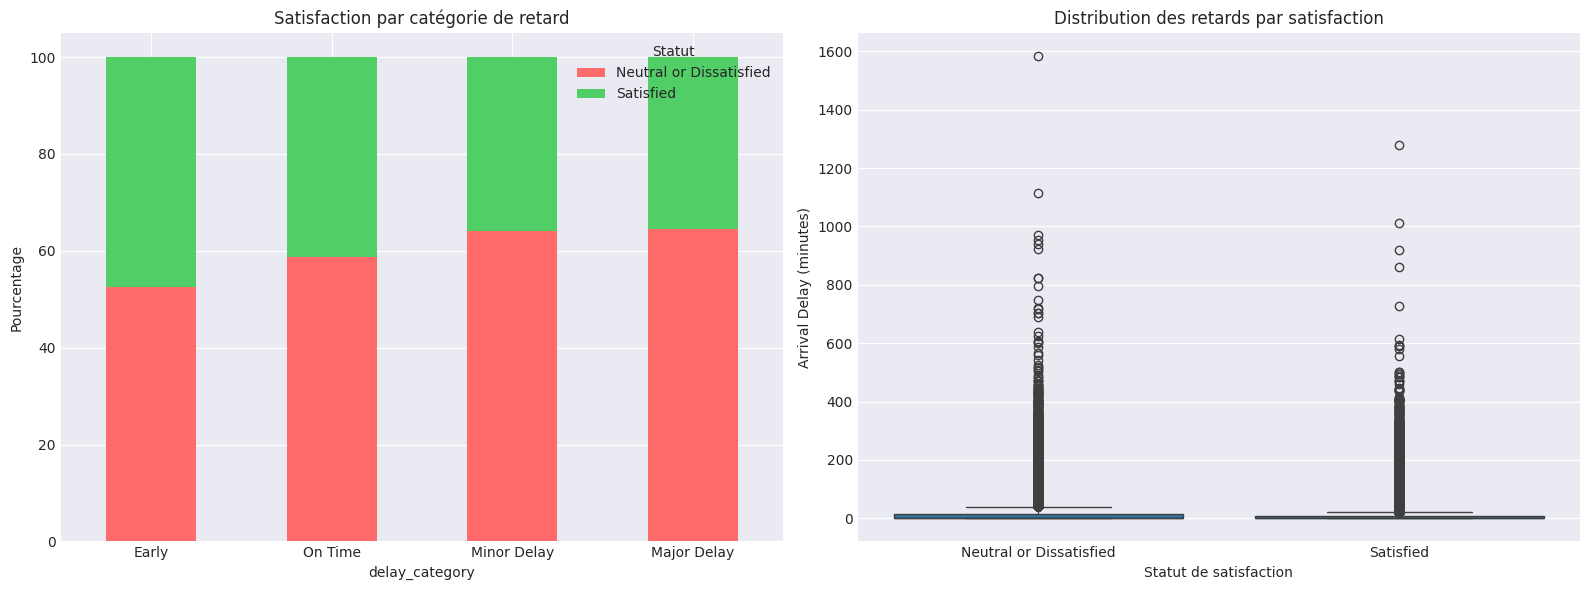

In [6]:
# Catégorisation des retards (en Python)
df_fact_review['delay_category'] = pd.cut(
    df_fact_review['arrival_delay'],
    bins=[-100, 0, 15, 60, 1000],
    labels=['Early', 'On Time', 'Minor Delay', 'Major Delay']
)

delay_satisfaction = pd.crosstab(df_fact_review['delay_category'], 
                               df_fact_review['satisfaction_status'], 
                               normalize='index') * 100

print("📊 Satisfaction par catégorie de retard:")
print(f"\n{delay_satisfaction.round(1)}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

delay_satisfaction.plot(kind='bar', stacked=True, ax=axes[0], 
                    color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Satisfaction par catégorie de retard')
axes[0].set_ylabel('Pourcentage')
axes[0].legend(title='Statut')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df_fact_review, x='satisfaction_status', 
            y='arrival_delay', ax=axes[1])
axes[1].set_title('Distribution des retards par satisfaction')
axes[1].set_xlabel('Statut de satisfaction')
axes[1].set_ylabel('Arrival Delay (minutes)')

plt.tight_layout()
plt.show()

## 7. Exploration DIM_CLIENT - Profils clients

In [7]:
# Lecture requête depuis fichier SQL
with open(SQL_DIR / "01_extraction_dwh.sql", 'r') as f:
    full_sql = f.read()

# Extraire la requête DIM_CLIENT
import re
match = re.search(r'-- Extraction DIM_CLIENT.*?(?=\n\n|--|$)', full_sql, re.DOTALL)
if match:
    query_dim_client = match.group(0).strip()
else:
    query_dim_client = "SELECT * FROM DIM_CLIENT WHERE is_current = 1;"

df_dim_client = pd.read_sql(query_dim_client, engine)

print(f"📊 DIM_CLIENT: {df_dim_client.shape}")
print(f"\nColonnes: {list(df_dim_client.columns)}")
print(f"\nAperçu:")
display(df_dim_client.head())

📊 DIM_CLIENT: (16737, 14)

Colonnes: ['client_sk', 'loyalty_number', 'country', 'province', 'city', 'gender', 'education', 'salary_band', 'marital_status', 'loyalty_card', 'clv', 'clv_quartile', 'is_churned', 'tenure_months']

Aperçu:


,client_sk,loyalty_number,country,province,city,gender,education,salary_band,marital_status,loyalty_card,clv,clv_quartile,is_churned,tenure_months
0,1,480934,CANADA,ONTARIO,TORONTO,F,Bachelor,High,Married,Star,3839.14,2,False,123
1,2,549612,CANADA,ALBERTA,EDMONTON,M,College,Medium,Divorced,Star,3839.61,2,False,122
2,3,429460,CANADA,BRITISH COLUMBIA,VANCOUVER,M,College,Medium,Single,Star,3839.75,2,True,42
3,4,608370,CANADA,ONTARIO,TORONTO,M,College,Medium,Single,Star,3839.75,2,False,159
4,5,530508,CANADA,QUEBEC,HULL,M,Bachelor,High,Married,Star,3842.79,2,False,139


## 8. Résumé

In [8]:
print("""\n
╔═══════════════════════════════════════════════════════════════╗
║            ✅ EXPLORATION SQL TERMINÉE                         ║
╚═════════════════════════════════════════════════════════════════════════════╗
╔═══════════════════════════════════════════════════════════════════════════════╝

📊 Tables explorées:
   • FACT_REVIEW (129,880 lignes)
   • DIM_CLIENT (16,737 lignes)

🔍 Principales observations:
   • Distribution satisfaction à analyser
   • Scores de service à corréler
   • Impact des retards à vérifier
   • Profils clients disponibles pour enrichissement

📂 Requêtes SQL stockées dans: {SQL_DIR}/

📝 Prochaine étape:
   • 02_exploration_csv.ipynb - Données CSV
""")



╔═══════════════════════════════════════════════════════════════╗
║            ✅ EXPLORATION SQL TERMINÉE                         ║
╚═════════════════════════════════════════════════════════════════════════════╗
╔═══════════════════════════════════════════════════════════════════════════════╝

📊 Tables explorées:
   • FACT_REVIEW (129,880 lignes)
   • DIM_CLIENT (16,737 lignes)

🔍 Principales observations:
   • Distribution satisfaction à analyser
   • Scores de service à corréler
   • Impact des retards à vérifier
   • Profils clients disponibles pour enrichissement

📂 Requêtes SQL stockées dans: {SQL_DIR}/

📝 Prochaine étape:
   • 02_exploration_csv.ipynb - Données CSV

